In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns  
from tqdm.auto import tqdm 

c:\Users\J Birbou\ML_Class\ml_env6\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


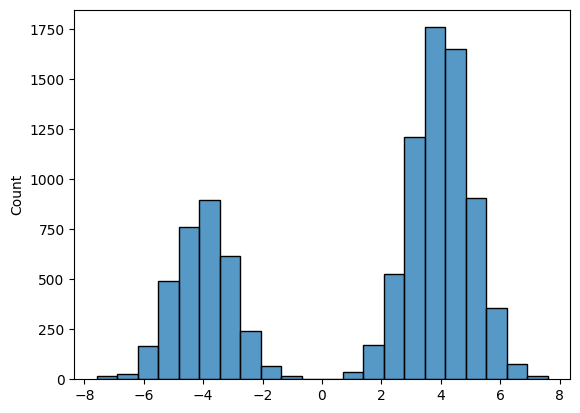

In [ ]:

data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1, 2])),
    torch.distributions.Normal(torch.tensor([-4., 4.]), torch.tensor([1., 1.]))
)

dataset = data_distribution.sample(torch.Size([10000]))  # create training data set
dataset_validation = data_distribution.sample(torch.Size([1000])) # create validation data set
fig, ax = plt.subplots(1, 1)
sns.histplot(dataset)
plt.show()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = dataset.to(device)
dataset_validation = dataset_validation.to(device)


In [ ]:

TIME_STEPS = 250
BETA = torch.tensor(0.02, device=device)
alpha = 1.0 - BETA
N_EPOCHS = 1000
BATCH_SIZE = 64
LEARNING_RATE = 0.8e-4
alpha_bar_all = alpha ** torch.arange(0, TIME_STEPS + 1, device=device)


In [ ]:

import torch.nn as nn

def MLP(in_channels=2):
    return nn.Sequential(
        nn.Linear(2, 256),
            nn.SiLU(),
            
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.SiLU(),
            
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.SiLU(),
            
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.SiLU(),
            
            nn.Linear(128, 1)
    )

g = MLP(in_channels=2).to(device)  # the input is the current data and the time step, so we have 2 input channels
optimizer = torch.optim.Adam(g.parameters(), lr=LEARNING_RATE)


In [ ]:
#Training loop


epochs = tqdm(range(N_EPOCHS)) 
for e in epochs: 
    optimizer.zero_grad()
    g.train()
    indices = torch.randperm(dataset.shape[0], device=device)
    shuffled_dataset = dataset[indices]
    
    for i in range(0, shuffled_dataset.shape[0] - BATCH_SIZE, BATCH_SIZE):
        optimizer.zero_grad()
        x0 = shuffled_dataset[i:i + BATCH_SIZE]

        t = torch.randint(1, TIME_STEPS + 1, (BATCH_SIZE,), device=device) ############

        epsilon = torch.randn_like(x0)
        alpha_bar = alpha_bar_all[t]
        x_t = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1.0 - alpha_bar) * epsilon

        model_input = torch.stack([x_t, t.float()], dim=1) ################
        predicted_noise = g(model_input).squeeze() ################ 
        loss = torch.nn.functional.mse_loss(predicted_noise, epsilon) ################
        loss.backward()
        optimizer.step()



    g.eval()
    with torch.no_grad(): 
        x0_val = dataset_validation
        
        
        t_val = torch.randint(1, TIME_STEPS + 1, (dataset_validation.shape[0],), device=device)
        epsilon_val = torch.randn_like(x0_val)
        
        alpha_bar_val = alpha_bar_all[t_val]

        x_t_val = torch.sqrt(alpha_bar_val) * x0_val + torch.sqrt(1.0 - alpha_bar_val) * epsilon_val
        val_model_input = torch.stack([x_t_val, t_val.float()], dim=1)
        val_predicted_noise = g(val_model_input).squeeze()

        val_loss = torch.nn.functional.mse_loss(val_predicted_noise, epsilon_val)

        noise_mean = val_predicted_noise.mean().item()
        noise_std = val_predicted_noise.std().item()
        
        epochs.set_postfix(
            val_loss=f"{val_loss.item():.4f}",
            mean=f"{noise_mean:.4f}",
            std=f"{noise_std:.4f}"  
        )




100%|██████████| 1000/1000 [05:43<00:00,  2.91it/s, mean=-0.0887, std=0.8079, val_loss=0.3985]


In [ ]:

def sample_reverse(g, count):
    x_T = torch.randn(count, device=device)
    g.eval()
    with torch.no_grad():
        for t in range(TIME_STEPS, 0, -1):
            if t>1:
                z = torch.randn_like(x_T , device=device)
            else:
                z = torch.zeros_like(x_T, device=device)
            
            
            t_tensor = torch.full((count,), t, dtype=torch.float32, device=device) ############
            model_input = torch.stack([x_T, t_tensor], dim=1)
            predicted_noise = g(model_input).squeeze()
            x_T = (1 / torch.sqrt(alpha)) * (x_T - ((1 - alpha) / torch.sqrt(1 - alpha_bar_all[t])) * predicted_noise) + torch.sqrt(BETA) * z
    return x_T
    


In [ ]:

samples = sample_reverse(g, 1000)
samples = samples.detach().numpy()

fig, ax = plt.subplots(1, 1)
bins = np.linspace(-10, 10, 50)
sns.kdeplot(dataset, ax=ax, color='blue', label='True distribution', linewidth=2)
sns.histplot(samples, ax=ax, bins=bins, color='red', label='Sampled distribution', stat='density')
ax.legend()
ax.set_xlabel('Sample value')
ax.set_ylabel('Sample count')

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

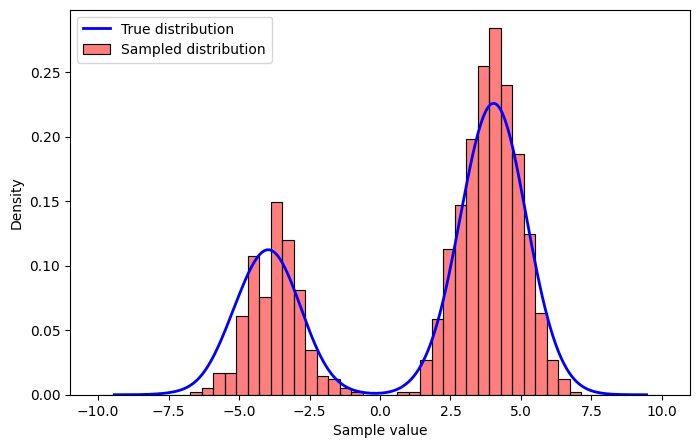

In [ ]:
import numpy as np

samples = sample_reverse(g, 1000)

samples = samples.cpu().numpy()
dataset_cpu = dataset.cpu().numpy()

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
bins = np.linspace(-10, 10, 50)

sns.kdeplot(dataset_cpu, ax=ax, color='blue', label='True distribution', linewidth=2)

sns.histplot(samples, ax=ax, bins=bins, color='red', label='Sampled distribution', stat='density', alpha=0.5)

ax.legend()
ax.set_xlabel('Sample value')

ax.set_ylabel('Density') 

plt.show()